### Functions 
<blockquote>Read user JSON data</blockquote>
<blockquote>Remove invalid Android Jump Flight Time</blockquote>
<blockquote>Detect Outliers</blockquote>

In [1]:
import pandas as pd
import numpy as np
import os
import json

NUMERIC_COLUMNS = [
    "Number:",
    "Jump Flight Time (Android):",
    "Jump Flight Time (BioPlux):",
    "Age:",
    "Weight:",
    "Height:",
]
# total 16 trials (invalid Android jump flight time)
INVALID_ANDROID_VALUES = {
    1174, 694, 676, 679, 1156, 1170,
    710, 774, 755, 875, 811,
    66, 34, 82, 1214, 148,
}
GENDER_ENCODING = {"Male": 1, "Female": 0}

def load_and_clean_data(base_path):
    
    all_folders = sorted([
        os.path.join(base_path, f)
        for f in os.listdir(base_path)
        if f.isdigit()
    ])
    
    results = []
    
    for folder in all_folders:
        try:
            json_path = os.path.join(folder, "user_data.json")
            
            if os.path.exists(json_path):
                with open(json_path, "r") as f:
                    user_data = json.load(f)
                results.append(user_data)

        except Exception as e:
            print(f"Problem in folder {folder}: {e}")
    
    df = pd.DataFrame(results)
    
    for col in NUMERIC_COLUMNS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=NUMERIC_COLUMNS)

    before = len(df)
    df = df[~df['Jump Flight Time (Android):'].isin(INVALID_ANDROID_VALUES)]
    print(f"Manually removed {before - len(df)} invalid rows")

    # Encode Gender Male=>1 Female=>0
    if 'Gender' in df.columns:
        df['Gender'] = df['Gender'].map(GENDER_ENCODING)

    return df
    
def detect_outliers(series, threshold=2):
    # Outlier detection on jump flight time only
    z_scores = np.abs((series - series.mean()) / series.std())
    return z_scores > threshold

## main LSQ VS MLP

Manually removed 16 invalid rows
Data dimension : (534, 7)
     Number:  Age:  Weight:  Height:  Gender  Jump Flight Time (Android):  \
0          1    31       70      175       1                          429   
111        2    31       70      175       1                          429   
222        3    31       70      175       1                          421   
333        4    31       70      175       1                          420   
444        5    31       70      175       1                          403   
..       ...   ...      ...      ...     ...                          ...   
496      546    22       78      170       1                          413   
497      547    22       78      170       1                          313   
498      548    22       78      170       1                          364   
499      549    22       78      170       1                          362   
501      550    22       78      170       1                          380   

     Jump Flight

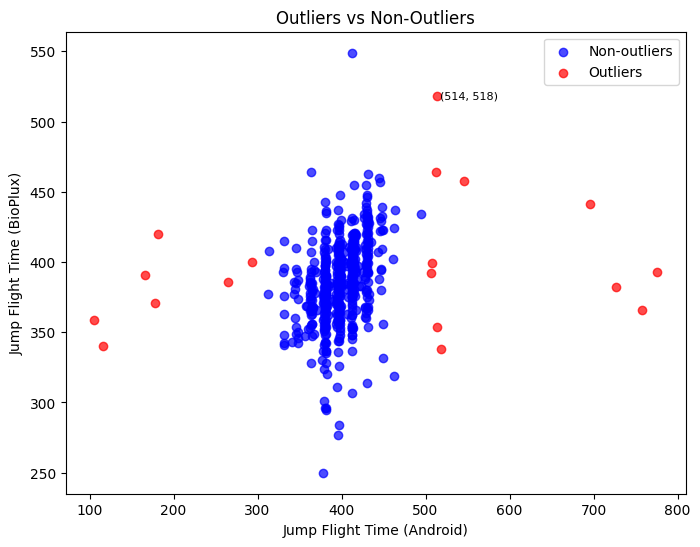

Outliers exported to ./Extractions/outliers.csv
Data dimension after cleaning outliers: (516, 5)
     Jump Flight Time (Android):  Age:  Weight:  Height:  Gender
0                            429    31       70      175       1
1                            429    31       70      175       1
2                            421    31       70      175       1
3                            420    31       70      175       1
4                            403    31       70      175       1
..                           ...   ...      ...      ...     ...
511                          413    22       78      170       1
512                          313    22       78      170       1
513                          364    22       78      170       1
514                          362    22       78      170       1
515                          380    22       78      170       1

[516 rows x 5 columns]

*** Linear (LSQ) ***
MSE: 773.5509522040928
R² : 0.15524458581761458

*** MLP ***
MSE: 774.8472512

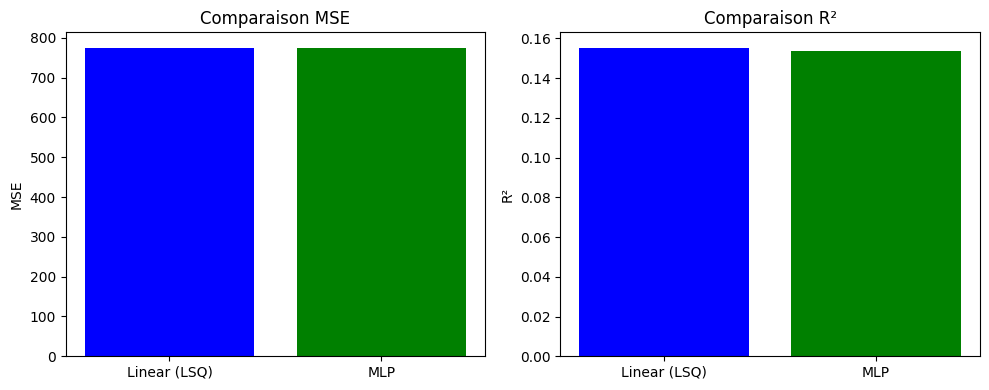

In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = load_and_clean_data("./TempoVooDataset")
print("Data dimension :", df.shape)
df = df.sort_values(by="Number:")
print(df)
# Data preparation
feature_cols = ['Jump Flight Time (Android):', 'Age:', 'Weight:', 'Height:', 'Gender']
X = df[feature_cols]
y = df['Jump Flight Time (BioPlux):']
    
# Outlier detection on jump flight time only
outliers = detect_outliers(df['Jump Flight Time (Android):'], threshold=2)
print(f"Number of outliers detected : {outliers.sum()}")

# Plot Outliers vs Non-Outliers
plt.figure(figsize=(8,6))
# Non-outliers
plt.scatter(
    X.loc[~outliers, 'Jump Flight Time (Android):'],
    y[~outliers],
    label="Non-outliers",
    alpha=0.7,
    c="blue"
)
# Outliers
plt.scatter(
    X.loc[outliers, 'Jump Flight Time (Android):'],
    y[outliers],
    label="Outliers",
    alpha=0.7,
    c="red"
)

# Write the text right next to the point (514, 518) as example of zscore 
plt.text(
    517, 518,              # (x, y) position slightly to the right of the point
    "(514, 518)", 
    fontsize=8, 
    color="black", 
    va="center"
)
plt.xlabel("Jump Flight Time (Android)")
plt.ylabel("Jump Flight Time (BioPlux)")
plt.title("Outliers vs Non-Outliers")
plt.legend()
# Save Outliers plot
plt.savefig("./images/outliers.png", dpi=300, bbox_inches='tight')
plt.show()

# Extract Outliers and export to CSV
df_outliers = df[outliers]
df_outliers.to_csv("./Extractions/outliers.csv", index=False)
print("Outliers exported to ./Extractions/outliers.csv")

# Deleting outliers
X_clean = X[~outliers].reset_index(drop=True)
y_clean = y[~outliers].reset_index(drop=True)
print("Data dimension after cleaning outliers:", X_clean.shape)
print(X_clean)

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_clean, test_size=0.2, random_state=42)

# Linear (LSQ)
lin = LinearRegression()
lin.fit(X_train, y_train)
y_pred_lin = lin.predict(X_test)

# MLP
mlp = MLPRegressor(hidden_layer_sizes=(64,32,16),
                   alpha=0.010,
                   max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

# Comparing 2 modeles
models = ["Linear (LSQ)", "MLP"]
# Comparing 2 modeles MSE score
mse_scores = [
    mean_squared_error(y_test, y_pred_lin),
    mean_squared_error(y_test, y_pred_mlp)
]
# Comparing 2 modeles R2 score
r2_scores = [
    r2_score(y_test, y_pred_lin),
    r2_score(y_test, y_pred_mlp)
]

for i, model in enumerate(models):
    print(f"\n*** {model} ***")
    print("MSE:", mse_scores[i])
    print("R² :", r2_scores[i])

# Comparative plot
plt.figure(figsize=(10,4))

# MSE 
plt.subplot(1,2,1)
plt.bar(models, mse_scores, color=['blue','green','red','orange'])
plt.title("Comparaison MSE")
plt.ylabel("MSE")

# R²
plt.subplot(1,2,2)
plt.bar(models, r2_scores, color=['blue','green','red','orange'])
plt.title("Comparaison R²")
plt.ylabel("R²")
plt.tight_layout()

# Save the plot
plt.savefig("./images/MSEvsR2.png", dpi=300, bbox_inches='tight')
plt.show()

### Predicted LSQ & MLP all trials Jump Flight Time

In [3]:
# Load full dataset
df_full = load_and_clean_data("./TempoVooDataset")

# Reuse previously detected outliers
outlier_mask = df_full.index.isin(df_outliers.index) if 'df_outliers' in globals() else pd.Series(False, index=df_full.index)
valid_mask = ~outlier_mask

# Prepare feature matrix (must match training features exactly)
X_full = df_full[X_clean.columns]

# Initialize prediction columns
df_full["Predicted_LSQ"] = np.nan
df_full["Predicted_MLP"] = np.nan

# Scale features
X_valid_scaled = scaler.transform(X_full.loc[valid_mask])

# Make predictions
df_full.loc[valid_mask, "Predicted_LSQ"] = lin.predict(X_valid_scaled)
df_full.loc[valid_mask, "Predicted_MLP"] = mlp.predict(X_valid_scaled)

# NOW convert Gender only for presentation (optional)
if 'Gender' in df_full.columns:
    df_full["Gender"] = df_full["Gender"].map({1: "Male", 0: "Female"})

print(df_full)

# Save outputs
os.makedirs("./Extractions", exist_ok=True)
df_full.to_csv("./Extractions/predicted_LSQ_MLP.csv", index=False)

print("Predictions saved to ./Extractions/")

Manually removed 16 invalid rows
     Number:  Age:  Weight:  Height: Gender  Jump Flight Time (Android):  \
0          1    31       70      175   Male                          429   
1         10    31       70      175   Male                          397   
3        101    22       78      170   Male                          430   
4        102    22       78      170   Male                          429   
5        103    22       78      170   Male                          398   
..       ...   ...      ...      ...    ...                          ...   
545       95    22       78      170   Male                          430   
546       96    22       78      170   Male                          429   
547       97    22       78      170   Male                          430   
548       98    22       78      170   Male                          448   
549       99    22       78      170   Male                          445   

     Jump Flight Time (BioPlux):  Predicted_LSQ  Predi

### Metrics LSQ VS MLP
<h6>Mean Error</h6>
<h6>Mean Absolute Error</h6>
<h6>Standard Deviation of Absolute Error</h6>
<h6>Maximum Error</h6>
<h6>Minimum Error</h6>

In [4]:
# Ensure output folder exists
os.makedirs("./Extractions", exist_ok=True)

# --- Step 1: Remove rows with empty predictions ---
df_valid = df_full.dropna(subset=["Predicted_LSQ", "Predicted_MLP"]).copy()

# --- Step 2: Calculate percentage errors (only valid rows) ---
df_valid['Error_LSQ'] = (
    (df_valid['Predicted_LSQ'] - df_valid['Jump Flight Time (BioPlux):']) 
    / df_valid['Jump Flight Time (BioPlux):']
) * 100

df_valid['Abs_Error_LSQ'] = df_valid['Error_LSQ'].abs()

df_valid['Error_MLP'] = (
    (df_valid['Predicted_MLP'] - df_valid['Jump Flight Time (BioPlux):']) 
    / df_valid['Jump Flight Time (BioPlux):']
) * 100

df_valid['Abs_Error_MLP'] = df_valid['Error_MLP'].abs()

# --- Step 3: Compute summary metrics ---
metrics = {
    "LSQ": {
        "Mean Error (%)": df_valid['Error_LSQ'].mean(),
        "Mean Absolute Error (%)": df_valid['Abs_Error_LSQ'].mean(),
        "Std Absolute Error (%)": df_valid['Abs_Error_LSQ'].std(),
        "Max Error (%)": df_valid['Abs_Error_LSQ'].max(),
        "Min Error (%)": df_valid['Abs_Error_LSQ'].min()
    },
    "MLP": {
        "Mean Error (%)": df_valid['Error_MLP'].mean(),
        "Mean Absolute Error (%)": df_valid['Abs_Error_MLP'].mean(),
        "Std Absolute Error (%)": df_valid['Abs_Error_MLP'].std(),
        "Max Error (%)": df_valid['Abs_Error_MLP'].max(),
        "Min Error (%)": df_valid['Abs_Error_MLP'].min()
    }
}

metrics_df = pd.DataFrame(metrics)
metrics_df.index.name = "Metric"
metrics_df = metrics_df.reset_index()

# --- Step 4: Save to CSV ---
metrics_df.to_csv("./Extractions/metrics.csv", index=False)

# --- Step 5: Print metrics ---
print("\n=== Prediction Metrics (Empty predictions removed) ===\n")
print(metrics_df)
print("\nSaved to './Extractions/metrics.csv'")


=== Prediction Metrics (Empty predictions removed) ===

                    Metric        LSQ        MLP
0           Mean Error (%)   0.425573   1.232176
1  Mean Absolute Error (%)   5.321006   5.358723
2   Std Absolute Error (%)   5.433640   5.625011
3            Max Error (%)  50.495192  50.800615
4            Min Error (%)   0.016122   0.005337

Saved to './Extractions/metrics.csv'
